In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("global_ads_performance.csv")

In [3]:
df.head()


,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


In [4]:
df.tail()

,date,platform,campaign_type,industry,country,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
1795,2024-07-11,TikTok Ads,Video,E-commerce,Germany,180128,10555,0.0586,0.84,8866.20,707,12.54,200566.90,22.62
1796,2024-06-23,Meta Ads,Display,EdTech,Australia,169849,5927,0.0349,0.94,5571.38,437,12.75,105321.92,18.90
1797,2024-03-01,Meta Ads,Video,Fintech,Australia,122974,2939,0.0239,1.85,5437.15,91,59.75,26004.98,4.78
1798,2024-08-02,Google Ads,Search,E-commerce,USA,28553,850,0.0298,2.06,1751.00,51,34.33,13010.72,7.43
1799,2024-01-29,Meta Ads,Display,EdTech,UK,77447,906,0.0117,1.15,1041.90,29,35.93,8284.13,7.95


In [5]:
df.shape

(1800, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1800 non-null   object 
 1   platform       1800 non-null   object 
 2   campaign_type  1800 non-null   object 
 3   industry       1800 non-null   object 
 4   country        1800 non-null   object 
 5   impressions    1800 non-null   int64  
 6   clicks         1800 non-null   int64  
 7   CTR            1800 non-null   float64
 8   CPC            1800 non-null   float64
 9   ad_spend       1800 non-null   float64
 10  conversions    1800 non-null   int64  
 11  CPA            1800 non-null   float64
 12  revenue        1800 non-null   float64
 13  ROAS           1800 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 197.0+ KB


In [7]:
df["date"]=pd.to_datetime(df["date"])

In [8]:
df.describe()

,date,impressions,clicks,CTR,CPC,ad_spend,conversions,CPA,revenue,ROAS
count,1800,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,2024-06-28 12:56:00,102919.018889,3962.675556,0.038427,1.572756,6171.527272,181.562222,46.608961,30101.850450,6.450367
min,2024-01-01 00:00:00,5059.000000,91.000000,0.008900,0.280000,58.000000,2.000000,4.800000,142.690000,0.130000
25%,2024-03-27 18:00:00,54948.000000,1678.000000,0.025400,0.950000,1966.587500,59.000000,20.202500,7275.757500,2.170000
50%,2024-06-26 00:00:00,103653.000000,3318.000000,0.035550,1.460000,4393.860000,130.000000,33.375000,18362.965000,4.295000
75%,2024-09-26 00:00:00,150470.250000,5628.000000,0.049800,2.050000,8455.830000,252.250000,56.812500,38963.385000,8.212500
max,2024-12-30 00:00:00,199650.000000,16660.000000,0.095600,3.950000,38453.320000,1151.000000,335.860000,295028.260000,49.000000
std,NaN,55740.900690,2941.858037,0.017082,0.800872,5776.996958,171.424239,41.185556,34560.032941,6.590986


In [9]:
df.isnull().sum()

,0
date,0
platform,0
campaign_type,0
industry,0
country,0
impressions,0
clicks,0
CTR,0
CPC,0
ad_spend,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["CTR_calculated"]= df["clicks"]/df["impressions"]
df["CPC_calculated"]= df["ad_spend"]/df["clicks"]
df["CPA_calculated"]= df["ad_spend"]/df["conversions"]
df["ROAS_calculated"]= df["revenue"]/df["ad_spend"]

In [12]:
df["conversions_rate"]= df["conversions"]/df["clicks"]

In [13]:
df["CTR_calculated"] = df["CTR_calculated"].round(4)
df["CPC_calculated"] = df["CPC_calculated"].round(2)
df["CPA_calculated"] = df["CPA_calculated"].round(2)
df["ROAS_calculated"] = df["ROAS_calculated"].round(2)
df["conversions_rate"] = df["conversions_rate"].round(3)

In [14]:
df["ROAS_calculated"].head()

,ROAS_calculated
0,1.80
1,10.41
2,2.06
3,6.45
4,0.39


In [15]:
df["CTR_calculated"].describe()

,CTR_calculated
count,1800.000000
mean,0.038424
std,0.017081
min,0.008900
25%,0.025400
50%,0.035550
75%,0.049800
max,0.095600


In [16]:
df["CPC_calculated"].describe()

,CPC_calculated
count,1800.000000
mean,1.572756
std,0.800872
min,0.280000
25%,0.950000
50%,1.460000
75%,2.050000
max,3.950000


In [17]:
df["CPA_calculated"].describe()

,CPA_calculated
count,1800.000000
mean,46.608928
std,41.185556
min,4.800000
25%,20.202500
50%,33.375000
75%,56.812500
max,335.860000


In [18]:
df["ROAS_calculated"].describe()

,ROAS_calculated
count,1800.000000
mean,6.450367
std,6.590986
min,0.130000
25%,2.170000
50%,4.295000
75%,8.212500
max,49.000000


In [19]:
import matplotlib.pyplot as plt

ROAS Distribution

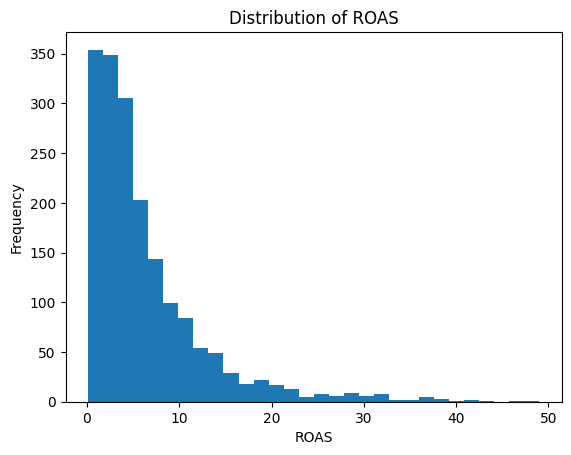

In [20]:
plt.hist(df["ROAS_calculated"], bins= 30)
plt.xlabel("ROAS")
plt.ylabel("Frequency")
plt.title("Distribution of ROAS")
plt.show()


CPA Distribution

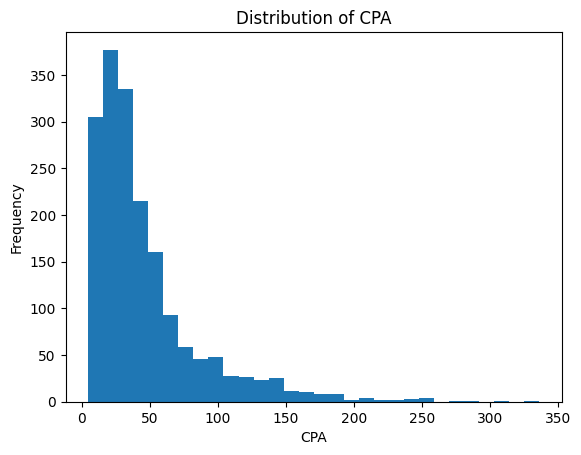

In [21]:
plt.hist(df["CPA_calculated"], bins= 30)
plt.xlabel("CPA")
plt.ylabel("Frequency")
plt.title("Distribution of CPA")
plt.show()

CPC Distribution

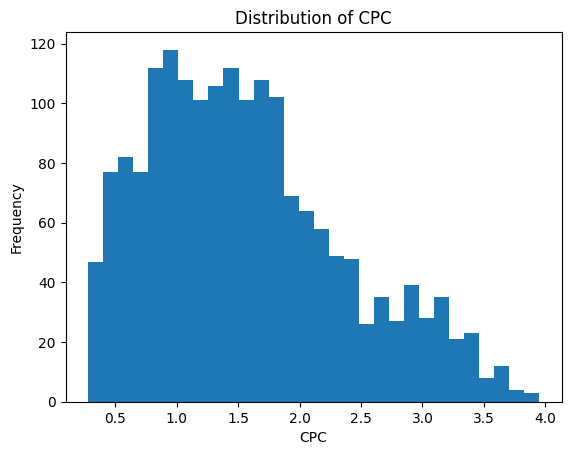

In [22]:
plt.hist(df["CPC_calculated"], bins= 30)
plt.xlabel("CPC")
plt.ylabel("Frequency")
plt.title("Distribution of CPC")
plt.show()

In [23]:
df["conversions_rate"].head()

,conversions_rate
0,0.075
1,0.079
2,0.045
3,0.050
4,0.024


Conversion Rate Distribution

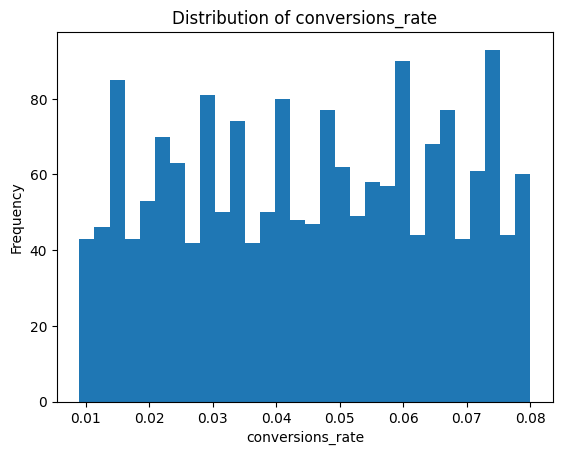

In [24]:
plt.hist(df["conversions_rate"], bins= 30)
plt.xlabel("conversions_rate")
plt.ylabel("Frequency")
plt.title("Distribution of conversions_rate")
plt.show()

In [25]:
Q1 = df["ROAS_calculated"].quantile(0.25)
Q3 = df["ROAS_calculated"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["ROAS_calculated"] < lower_bound) | (df["ROAS_calculated"] > upper_bound)]

len(outliers)

123

In [26]:
len(df)

1800

In [27]:
123 / len(df) * 100

6.833333333333333

In [28]:
df[df["ROAS_calculated"] > upper_bound].shape
df[df["ROAS_calculated"] < lower_bound].shape

(0, 19)

In [29]:
Q1 = df["CPC_calculated"].quantile(0.25)
Q3 = df["CPC_calculated"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["CPC_calculated"] < lower_bound) | (df["CPC_calculated"] > upper_bound)]

len(outliers)

7

In [30]:
Q1 = df["CPA_calculated"].quantile(0.25)
Q3 = df["CPA_calculated"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["CPA_calculated"] < lower_bound) | (df["CPA_calculated"] > upper_bound)]

len(outliers)

140

In [31]:
df[df["CPA_calculated"] > upper_bound]["CPA"].max()

335.86

In [32]:
df_clean = df.drop(columns=["CTR", "CPC", "CPA", "ROAS"])

In [33]:
df_clean = df_clean.rename(columns={
    "CTR_calc": "CTR",
    "CPC_calc": "CPC",
    "CPA_calc": "CPA",
    "ROAS_calc": "ROAS"
})

In [34]:
df_clean.to_csv("global_ads_clean.csv",
                index=False,
                encoding="utf-8")

In [35]:
####df_clean.to_csv("global_ad_performance_clean.csv", index=False)